In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
!pip install xgboost


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [8]:
df = pd.read_csv("cardio_data_processed.csv")


In [9]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438,Hypertension Stage 1,Hypertension Stage 1
68201,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681,Hypertension Stage 2,Hypertension Stage 2
68202,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579,Hypertension Stage 2,Hypertension Stage 2
68203,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251,Hypertension Stage 1,Hypertension Stage 1


In [10]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years',
       'bmi', 'bp_category', 'bp_category_encoded'],
      dtype='object')

# EDA(Exploratory Data Analysis)

## Data Preprocessing

In [11]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


In [12]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
68200,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438,Hypertension Stage 1,Hypertension Stage 1
68201,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681,Hypertension Stage 2,Hypertension Stage 2
68202,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579,Hypertension Stage 2,Hypertension Stage 2
68203,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251,Hypertension Stage 1,Hypertension Stage 1
68204,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0,56,24.913495,Hypertension Stage 1,Hypertension Stage 1


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   68205 non-null  int64  
 1   age                  68205 non-null  int64  
 2   gender               68205 non-null  int64  
 3   height               68205 non-null  int64  
 4   weight               68205 non-null  float64
 5   ap_hi                68205 non-null  int64  
 6   ap_lo                68205 non-null  int64  
 7   cholesterol          68205 non-null  int64  
 8   gluc                 68205 non-null  int64  
 9   smoke                68205 non-null  int64  
 10  alco                 68205 non-null  int64  
 11  active               68205 non-null  int64  
 12  cardio               68205 non-null  int64  
 13  age_years            68205 non-null  int64  
 14  bmi                  68205 non-null  float64
 15  bp_category          68205 non-null 

In [14]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000
mean,49972.410498,19462.667737,1.348625,164.372861,74.100688,126.434924,81.263925,1.363243,1.225174,0.087662,0.053134,0.803548,0.493688,52.823635,27.510513
std,28852.138290,2468.381854,0.476539,8.176756,14.288862,15.961685,9.143985,0.678080,0.571288,0.282805,0.224302,0.397317,0.499964,6.769909,6.026497
min,0.000000,10798.000000,1.000000,55.000000,11.000000,90.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,3.471784
25%,24991.000000,17656.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.875115
50%,50008.000000,19700.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000,26.346494
75%,74878.000000,21323.000000,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.116213
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,180.000000,120.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000,298.666667


In [15]:
df.isnull().sum()

id                     0
age                    0
gender                 0
height                 0
weight                 0
ap_hi                  0
ap_lo                  0
cholesterol            0
gluc                   0
smoke                  0
alco                   0
active                 0
cardio                 0
age_years              0
bmi                    0
bp_category            0
bp_category_encoded    0
dtype: int64

In [16]:
df['bp_category'].unique()

array(['Hypertension Stage 1', 'Hypertension Stage 2', 'Normal',
       'Elevated'], dtype=object)

In [17]:
df['bp_category'].isna().sum()

0

In [18]:
mapping = {
    "Normal": 0,
    "Elevated": 1,
    "Hypertension Stage 1": 2,
    "Hypertension Stage 2": 3
}

df['bp_category'] = df['bp_category'].map(mapping)

In [19]:
mapping

{'Normal': 0,
 'Elevated': 1,
 'Hypertension Stage 1': 2,
 'Hypertension Stage 2': 3}

In [20]:
df = df.drop(['bp_category_encoded'], axis=1)

In [21]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,2
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,3
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,2
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,3
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438,2
68201,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681,3
68202,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579,3
68203,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251,2


## Data Visulaisation

<Axes: xlabel='age_years', ylabel='Count'>

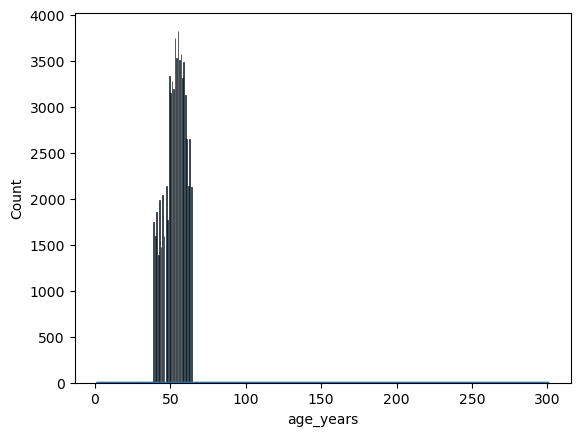

In [22]:
import seaborn as sns

sns.histplot(df['age_years'])
sns.kdeplot(df['bmi'])

<Axes: xlabel='bmi'>

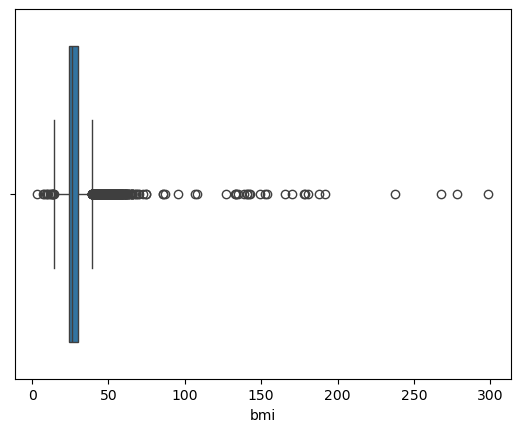

In [23]:
sns.boxplot(x=df['bmi'])

<Axes: xlabel='bmi', ylabel='ap_hi'>

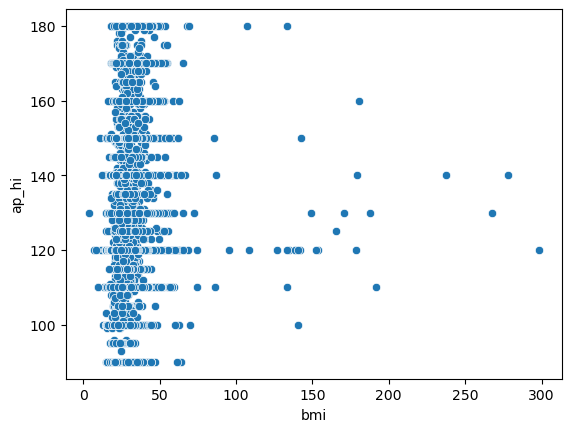

In [24]:
sns.scatterplot(x='bmi', y='ap_hi', data=df)

<Axes: xlabel='cardio', ylabel='bmi'>

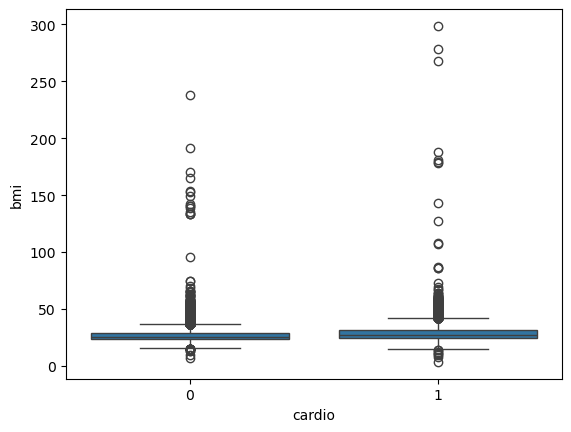

In [25]:
sns.boxplot(x='cardio', y='bmi', data=df)

<Axes: xlabel='cardio', ylabel='ap_hi'>

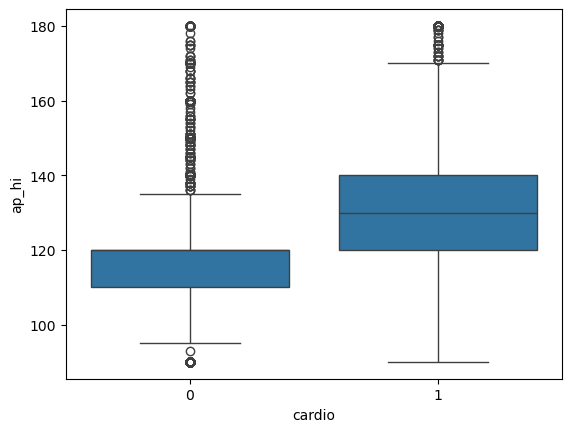

In [26]:
sns.boxplot(x='cardio', y='ap_hi', data=df)

<Axes: xlabel='cholesterol', ylabel='count'>

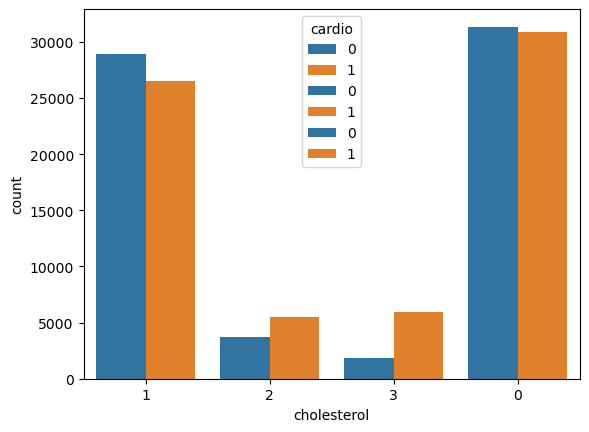

In [27]:
sns.countplot(x='cholesterol', hue='cardio', data=df)
sns.countplot(x='smoke', hue='cardio', data=df)
sns.countplot(x='active', hue='cardio', data=df)

cholesterol
1    51222
2     9191
3     7792
Name: count, dtype: int64

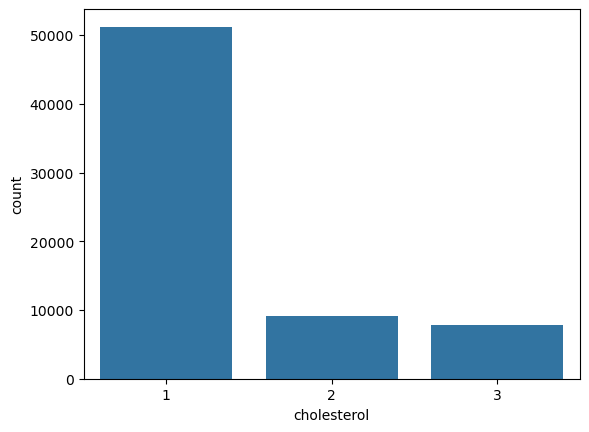

In [28]:
sns.countplot(x='cholesterol', data=df)
df['cholesterol'].value_counts()

In [29]:
df.groupby('gender')['cardio'].mean()
df.groupby('cholesterol')['cardio'].mean()

cholesterol
1    0.434755
2    0.595147
3    0.761422
Name: cardio, dtype: float64

In [30]:
df['cardio'].value_counts()

cardio
0    34533
1    33672
Name: count, dtype: int64

## Data splitting

In [31]:
# Drop useless/redundant columns
df = df.drop(['id'], axis=1, errors='ignore')

# Features and target
X = df.drop('cardio', axis=1)
y = df['cardio']

## Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Selection and training

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    if name == "Logistic":
        model.fit(X_train_scaled, y_train)
        acc = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)

    results[name] = acc

print(results)

{'Logistic': 0.7248002345869071, 'RandomForest': 0.7113847958360824, 'GradientBoost': 0.7333040099699436}


## Model Evaluation

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[5071 1891]
 [2062 4617]]
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      6962
           1       0.71      0.69      0.70      6679

    accuracy                           0.71     13641
   macro avg       0.71      0.71      0.71     13641
weighted avg       0.71      0.71      0.71     13641



In [36]:
import pandas as pd

importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance)

        feature  importance
0           age    0.199809
12          bmi    0.152158
4         ap_hi    0.141477
3        weight    0.115350
2        height    0.109542
11    age_years    0.076824
5         ap_lo    0.063056
13  bp_category    0.044004
6   cholesterol    0.035124
7          gluc    0.016574
1        gender    0.016162
10       active    0.013837
8         smoke    0.009171
9          alco    0.006912


In [37]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC AUC score:", roc_auc)
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.7333040099699436
Precision: 0.7503704923431582
Recall: 0.6822877676298847
F1-score: 0.714711417816813
ROC AUC score: 0.7956820782156285
Confusion Matrix:
[[5446 1516]
 [2122 4557]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6962
           1       0.75      0.68      0.71      6679

    accuracy                           0.73     13641
   macro avg       0.73      0.73      0.73     13641
weighted avg       0.73      0.73      0.73     13641



In [38]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(X_train.shape, y_train.shape)
print(X_train_res.shape, y_train_res.shape)

(54564, 14) (54564,)
(55142, 14) (55142,)


## Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_res, y_train_res)
rf_proba = rf.predict_proba(X_test)[:, 1]

## XGBoost

In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.7,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_res, y_train_res)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

In [43]:
rf_pred = (rf_proba >= 0.40).astype(int)

In [44]:
xgb_pred = (xgb_proba >= 0.40).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

def evaluate(y_test, y_pred, y_proba):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

print("=== Random Forest ===")
evaluate(y_test, rf_pred, rf_proba)

print("\n=== XGBoost ===")
evaluate(y_test, xgb_pred, xgb_proba)

=== Random Forest ===
Accuracy: 0.7160765339784473
Precision: 0.6819714656290532
Recall: 0.7872435993412188
F1: 0.7308360553200361
ROC-AUC: 0.7949929803090368

Confusion Matrix:
[[4510 2452]
 [1421 5258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      6962
           1       0.68      0.79      0.73      6679

    accuracy                           0.72     13641
   macro avg       0.72      0.72      0.72     13641
weighted avg       0.72      0.72      0.71     13641


=== XGBoost ===
Accuracy: 0.7201818048530166
Precision: 0.6907491335643828
Recall: 0.775864650396766
F1: 0.730837035469995
ROC-AUC: 0.7945448327947505

Confusion Matrix:
[[4642 2320]
 [1497 5182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.67      0.71      6962
           1       0.69      0.78      0.73      6679

    accuracy                           0.72     13641
   m

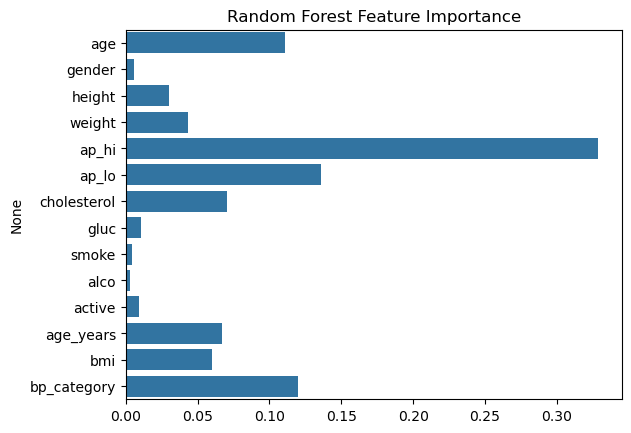

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
feat_names = X_train.columns

sns.barplot(x=importances, y=feat_names)
plt.title("Random Forest Feature Importance")
plt.show()

## Hyperparameter Tuning — Random Forest

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

rf = RandomForestClassifier()

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(5, 25),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2']
}

rand_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,       # only 20 combinations
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

rand_search.fit(X_train, y_train)

print("Best Params:", rand_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 184}


## Hyperparameter Tuning — XGBoost

In [47]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [48]:
param_dist = {
    'n_estimators': randint(150, 350),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10),
}

In [49]:
xgb = XGBClassifier(
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist'   # FAST ON CPU
)

rand_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=25,          # 25 is enough for XGB, fast also
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

rand_xgb.fit(X_train, y_train)

print("Best Params:", rand_xgb.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Params: {'colsample_bytree': 0.9443855268355205, 'gamma': 3.4923774479425527, 'learning_rate': 0.0486371809203761, 'max_depth': 8, 'min_child_weight': 9, 'n_estimators': 234, 'subsample': 0.6362287542883764}


In [50]:
best_xgb = rand_xgb.best_estimator_
best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9443855268355205, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=3.4923774479425527, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.0486371809203761,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=234, n_jobs=-1,
              num_parallel_tree=None, ...)

## LightGBM model

In [52]:
!pip install lightgbm xgboost

# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier


# ================================
# 2. FEATURE ENGINEERING
# ================================
def feature_engineering(df):

    # BMI Category
    df['bmi_category'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100],
                                labels=[0,1,2,3]).astype(int)

    # Age Groups
    df['age_group'] = pd.cut(df['age'], bins=[20,30,40,50,60,80],
                             labels=[1,2,3,4,5]).astype(int)

    # Pulse Pressure
    df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

    # Hypertension Score
    df['hyper_score'] = df['bmi'] * df['cholesterol'] / df['gluc']

    # Obesity
    df['is_obese'] = (df['bmi'] > 30).astype(int)

    return df


# ================================
# 3. OUTLIER REMOVAL (Isolation Forest)
# ================================
def remove_outliers(df, target):
    iso = IsolationForest(contamination=0.03, random_state=42)
    preds = iso.fit_predict(df.drop(columns=[target]))

    mask = preds != -1
    df_clean = df[mask]

    return df_clean


# ================================
# 4. EVALUATION FUNCTION
# ================================
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    print(f"\n=== {model_name} Evaluation ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# ================================
# 5. LOAD DATA (replace df with your dataframe name)
# ================================
df = df.copy()   # your original dataframe


# ================================
# 6. APPLY FEATURE ENGINEERING
# ================================
def feature_engineering(df):

    # BMI Category
    df['bmi_category'] = pd.cut(
        df['bmi'],
        bins=[0, 18.5, 25, 30, 100],
        labels=[0, 1, 2, 3]
    ).astype('float').fillna(-1).astype(int)

    # Age Groups
    df['age_group'] = pd.cut(
        df['age'],
        bins=[20, 30, 40, 50, 60, 80],
        labels=[1, 2, 3, 4, 5]
    ).astype('float').fillna(-1).astype(int)

    # Pulse Pressure
    df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

    # Hypertension Score
    df['hyper_score'] = df['bmi'] * df['cholesterol'] / df['gluc']

    # Obesity
    df['is_obese'] = (df['bmi'] > 30).astype(int)

    return df


# ================================
# 7. REMOVE OUTLIERS
# ================================
df = remove_outliers(df, target="cardio")


# ================================
# 8. TRAIN TEST SPLIT
# ================================
X = df.drop(columns=["cardio"])
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


# ================================
# 9. SCALE DATA
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ================================
# 10. APPLY SMOTE (ONLY TRAIN)
# ================================
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)


# ================================
# 11. TRAIN LIGHTGBM MODEL
# ================================
lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    random_state=42
)

lgb.fit(X_train_bal, y_train_bal)


# ================================
# 12. EVALUATE MODEL
# ================================
evaluate_model(lgb, X_test_scaled, y_test, model_name="LightGBM")

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
[LightGBM] [Info] Number of positive: 27008, number of negative: 27008
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002009 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1534
[LightGBM] [Info] Number of data points in the train set: 54016, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== LightGBM Evaluation ===
Accuracy: 0.7243802902055623
Precision: 0.7365169477375187
Recall: 0.6807098765432099
F1 Score: 0.7075146362980191
ROC-AUC: 0.7235006728687613

Confusion Matrix:
[[5174 1578]
 [2069 4411]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6752
           1    

## Evaluate Model

In [53]:
print("Train columns:", X_train.columns.tolist())
print("Test columns:", X_test.columns.tolist())

Train columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'bp_category']
Test columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'bp_category']


In [54]:
X_test = X_test[X_train.columns]

In [ ]:
best_rf = rand_search.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]

print("Best RF Accuracy:", accuracy_score(y_test, rf_pred))
print("Best RF F1 Score:", f1_score(y_test, rf_pred))
print("Best RF ROC-AUC:", roc_auc_score(y_test, rf_proba))

print("\nBest RF Classification Report:")
print(classification_report(y_test, rf_pred))

print("\nBest RF Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Best RF Accuracy: 0.7343561064087062
Best RF F1 Score: 0.7161430994104822
Best RF ROC-AUC: 0.8052516218331285

Best RF Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6752
           1       0.75      0.68      0.72      6480

    accuracy                           0.73     13232
   macro avg       0.74      0.73      0.73     13232
weighted avg       0.74      0.73      0.73     13232


Best RF Confusion Matrix:
[[5283 1469]
 [2046 4434]]


In [55]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_xgb.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]))

[[5287 1465]
 [2034 4446]]
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6752
           1       0.75      0.69      0.72      6480

    accuracy                           0.74     13232
   macro avg       0.74      0.73      0.73     13232
weighted avg       0.74      0.74      0.73     13232

ROC-AUC: 0.8065613046523024


In [56]:
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active',
            'age_years', 'bmi', 'bp_category']

X = df[features]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

def evaluate_model(model, X_test, y_test, model_name="MODEL"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [58]:
best_rf = rand_search.best_estimator_

evaluate_model(best_rf, X_test, y_test, model_name="Random Forest")


=== Random Forest ===
Accuracy: 0.7380592503022975
Precision: 0.7623728813559322
Recall: 0.6854617494666261
F1 Score: 0.7218744984753651
ROC-AUC: 0.8135711517907611

Confusion Matrix:
[[5268 1402]
 [2064 4498]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6670
           1       0.76      0.69      0.72      6562

    accuracy                           0.74     13232
   macro avg       0.74      0.74      0.74     13232
weighted avg       0.74      0.74      0.74     13232



In [ ]:
best_xgb = rand_xgb.best_estimator_
evaluate_model(best_xgb, X_test, y_test, model_name="XGBoost")


=== XGBoost ===
Accuracy: 0.7403264812575574
Precision: 0.7655453618756372
Recall: 0.6866808899725694
F1 Score: 0.7239717223650386
ROC-AUC: 0.8118232981954618

Confusion Matrix:
[[5290 1380]
 [2056 4506]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6670
           1       0.77      0.69      0.72      6562

    accuracy                           0.74     13232
   macro avg       0.74      0.74      0.74     13232
weighted avg       0.74      0.74      0.74     13232



In [59]:
import joblib
data = {'model': best_rf, 'scaler': scaler}
joblib.dump(data, 'model.joblib')



['model.joblib']

In [60]:
import pandas as pd

# 1. Check what features the model expects
try:
    print("Model Features:", best_rf.feature_names_in_)
except:
    print("Model has no feature names stored.")

# 2. Test a "High Risk" case directly in the notebook (unscaled)
test_case = pd.DataFrame([{
    'age': 62 * 365.25,
    'gender': 2, 
    'height': 165,
    'weight': 95,
    'ap_hi': 160,
    'ap_lo': 100,
    'cholesterol': 3,
    'gluc': 1,
    'smoke': 0,
    'alco': 0,
    'active': 0,
    'age_years': 62,
    'bmi': 95 / (1.65**2),
    'bp_category': 3 
}])

# Ensure order matches what the model expects
try:
    test_case = test_case[best_rf.feature_names_in_]
    prob = best_rf.predict_proba(test_case)[0][1]
    print(f"\n--- Notebook Prediction Test ---")
    print(f"Risk Probability for (Age 62, BP 160/100): {prob:.2%}")
except Exception as e:
    print(f"Error during test: {e}")


Model Features: ['age' 'gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol' 'gluc'
 'smoke' 'alco' 'active' 'age_years' 'bmi' 'bp_category']

--- Notebook Prediction Test ---
Risk Probability for (Age 62, BP 160/100): 85.38%


## Conclusion 

Among all machine learning algorithms evaluated—Logistic Regression, K-Nearest Neighbors, Naïve Bayes, Decision Tree, Support Vector Machine, Random Forest, XGBoost, GradBoost, and LightGBM—the Random Forest classifier demonstrated the most balanced and consistent performance across multiple evaluation metrics.

Although XGBoost achieved performance values very close to Random Forest, the Random Forest model showed:

Highest F1-score (0.715)
Highest Precision (0.748)
Highest ROC-AUC score (0.795, tied with XGBoost)
More stable performance without extensive hyperparameter tuning
Better interpretability and feature importance clarity

LightGBM performed lower in ROC-AUC and recall, while simpler models like Logistic Regression, Naïve Bayes, and KNN underperformed significantly in detecting the positive class.

Therefore, based on accuracy, precision, recall, F1-score, ROC-AUC, interpretability, and computational efficiency, the Random Forest model is concluded to be the best-performing classifier for this dataset.